In [1]:
import pandas as pd

data = pd.read_csv("student_data.csv")

print(data.head())
print("-"*50)
print(data.info())
print("-"*50)
print(data.describe())

   study_hours  attendance  previous_marks  sleep_hours  social_media_hours  \
0            5          85              78            7                   2   
1            3          60              65            6                   4   
2            8          90              88            7                   1   
3            2          50              55            5                   5   
4            6          75              70            6                   3   

   final_score  
0           80  
1           55  
2           92  
3           48  
4           72  
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   study_hours         94 non-null     int64
 1   attendance          94 non-null     int64
 2   previous_marks      94 non-null     int64
 3   sleep_hours         94 non-null     int64

In [2]:
#check missing values
print(data.isnull().sum())

study_hours           0
attendance            0
previous_marks        0
sleep_hours           0
social_media_hours    0
final_score           0
dtype: int64


In [3]:
#if data is missing
data=data.dropna()

In [4]:
#split features & target
X = data.drop("final_score", axis=1)
y = data["final_score"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 11.220728077087514
Coefficients: [ 1.38607569  0.50509367  0.47403858 -1.97943802 -1.66922787]


In [8]:
y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.944423729096242
MSE: 1.3657018218649897
R2 Score: 0.9954083154109706


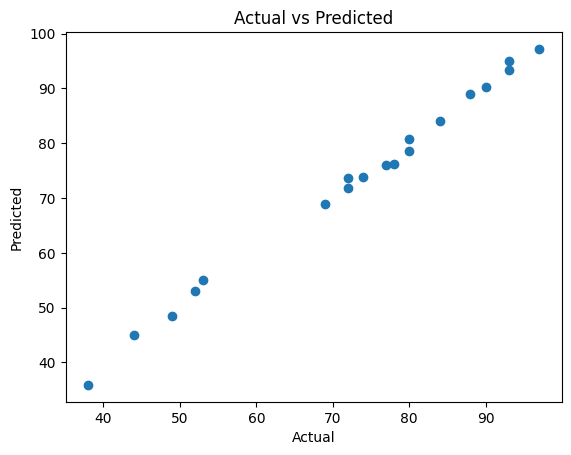

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [11]:
import numpy as np

sample = np.array([[6, 80, 75, 7, 2]])
prediction = model.predict(sample)

print("Predicted Score:", prediction[0])

Predicted Score: 78.30304751344507


e:\project\Linear_Regression_Project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
import pickle

with open("model.pkl","wb") as f:
    pickle.dump(model, f)